In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

os.environ["USE_PYGEOS"] = "0"
import geopandas as gpd

sys.path.append("../..")
from src import data_processing_projections
from src.data_processing_projections import DataProcessingDask

import dask
from dask.diagnostics import ProgressBar

import matplotlib.pyplot as plt

# Load

In [3]:
paths = json.load(open("../../paths_projections.json"))

path_data = Path(paths["path_data_ror"])

path_data_hydro = path_data / "hydropower"
path_data_polygons = path_data / "polygons"
path_swiss_maps = path_data / "maps" / "swissboundaries3d_2023-01_2056_5728/"

path_figs = Path(paths["path_figs"])

In [4]:
dask.config.set(num_workers=15, threads_per_worker=16)
dask.config.set(
    {
        "distributed.worker.memory.target": 0.7,  # Spill to disk at 70%
        "distributed.worker.memory.spill": 0.8,  # Start spilling at 80%
        "distributed.worker.memory.pause": 0.9,  # Pause worker at 90%
        "array.chunk-size": "512MiB",
        "logging.distributed": "error",  # Less verbose logs
    }
)

In [5]:
# climate_model_chain = None
# climate_scenario = None

climate_model_chain = "CNRM-ALADIN63_CNRM-CERFACS-CNRM-CM5_r1i1p1"
climate_scenario = "rcp26"

In [6]:
prevah_grid_resolution = 500  # in meters

In [7]:
processing = DataProcessingDask(
    "../../paths_projections.json", climate_model_chain, climate_scenario
)

Loading data


In [8]:
if climate_model_chain is None and climate_scenario is None:
    df_prevah_pts_in_polygons_filename = "df_prevah_obs_pts_in_polygons.csv"
else:
    df_prevah_pts_in_polygons_filename = "df_prevah_proj_pts_in_polygons.csv"

if processing.weighted:
    df_prevah_pts_in_polygons_filename = (
        df_prevah_pts_in_polygons_filename.removesuffix(".csv") + "_weighted.csv"
    )

In [9]:
climate_scenarios = ["rcp26", "rcp45", "rcp85"]
ds_gen_dict = {
    scenario: xr.open_zarr(
        processing.path_data_hydro
        / "hydropower_generation"
        / f"ds_prevah_{processing.climate_model_chain}_{scenario}_hydropower_production_ror.zarr",
        chunks="auto",
    )
    for scenario in climate_scenarios
}

ds_gen_rcp26 = ds_gen_dict["rcp26"]
ds_gen_rcp45 = ds_gen_dict["rcp45"]
ds_gen_rcp85 = ds_gen_dict["rcp85"]

# Analysis

In [11]:
periods = {"1991-2020": (1991, 2020), "2021-2050": (2021, 2050)}

In [12]:
def compute_yearly_sum_from_dataset(ds, value_name="gen_yearly"):
    """Compute yearly totals from a hydropower xarray.Dataset `ds` with data var `gen`.
    Returns (yearly_da, df, series, values) where:
      - yearly_da: xarray.DataArray of yearly totals (time dimension)
      - df: pandas.DataFrame with columns ['time', value_name, 'year']
      - series: pandas.Series indexed by year with the yearly totals
      - values: numpy array of series values
    """
    yearly_gen = ds.gen.resample(time="YE").sum(dim="time").sum(dim="hydropower")
    yearly_da = yearly_gen
    df = yearly_da.to_dataframe(name=value_name).reset_index()
    df["year"] = df["time"].dt.year
    series = df.set_index("year")[value_name]
    values = series.to_numpy()
    return yearly_da, df, series, values

In [13]:
def compute_monthly_generation_from_ds(ds_gen, gdf_hydropower_locations, start_year=None, end_year=None, resample_rule="ME"):
    """
    For each year in ds_gen, sum monthly generation over hydropower plants that were
    already in operation that year according to gdf_hydropower_locations.
    Returns an xarray.Dataset concatenated over time with generation aggregated.
    """
    list_ds = []
    hp_all = ds_gen.hydropower.to_numpy()
    years = np.unique(ds_gen.time.dt.year.values)
    if start_year is not None:
        years = years[years >= int(start_year)]
    if end_year is not None:
        years = years[years <= int(end_year)]

    for y in years:
        wasta = gdf_hydropower_locations[
            (gdf_hydropower_locations["BeginningOfOperation"] <= int(y))
            & (gdf_hydropower_locations["WASTANumber"].isin(hp_all))
        ]["WASTANumber"].tolist()
        if not wasta:
            # skip years with no plants in operation (keeps function simple)
            continue
        ds_year = ds_gen.sel(hydropower=wasta, time=str(int(y)))
        ds_monthly = ds_year.resample(time=resample_rule).sum(dim=["hydropower", "time"])
        list_ds.append(ds_monthly)

    if not list_ds:
        raise ValueError("No monthly generation data produced (no matching plants/years).")

    return xr.concat(list_ds, dim="time").compute()

In [14]:
from sklearn.linear_model import TheilSenRegressor
from scipy.stats.mstats import theilslopes

def compute_theilsen_trends(df, col, periods=periods, alpha=0.95):
    """Compute Theil-Sen trends for `col` in `df` for the requested periods.
    Returns a pandas DataFrame indexed by period (same columns as previous df_trends).
    """
    rows = []
    for name, (y0, y1) in periods.items():
        dfp = df[(df.year >= y0) & (df.year <= y1)].copy()
        if dfp.empty:
            raise ValueError(f"No data for period {name} and column {col}")

        X = dfp["year"].to_numpy().reshape(-1, 1)
        y = dfp[col].to_numpy()

        try:
            slope, intercept, lo_slope, hi_slope = theilslopes(y, dfp["year"].to_numpy(), alpha=alpha)
            method = f"scipy.theilslopes ({int(alpha*100)}% CI)"
        except Exception:
            model = TheilSenRegressor(random_state=0)
            model.fit(X, y)
            slope = float(model.coef_[0])
            intercept = float(model.intercept_)
            lo_slope, hi_slope = (np.nan, np.nan)
            method = "sklearn.TheilSenRegressor (no CI)"

        slope_per_year = float(slope)
        slope_per_decade = slope_per_year * 10.0
        mean_val = y.mean()
        rel_per_decade_pct = 100.0 * (slope_per_decade / mean_val)

        rows.append(
            {
                "period": name,
                "n_years": len(dfp),
                "slope_TWh_per_year": slope_per_year,
                "slope_TWh_per_decade": slope_per_decade,
                "slope_CI_lower": lo_slope,
                "slope_CI_upper": hi_slope,
                "mean_TWh": mean_val,
                "rel_change_pct_per_decade": rel_per_decade_pct,
                "method": method,
            }
        )

    return pd.DataFrame(rows).set_index("period")

## Scenarios comparison

In [15]:
yearly_da_rcp26, df26, series26, yearly_values_rcp26 = compute_yearly_sum_from_dataset(ds_gen_rcp26, "gen_yearly")
yearly_da_rcp45, df45, series45, yearly_values_rcp45 = compute_yearly_sum_from_dataset(ds_gen_rcp45, "gen_yearly")
yearly_da_rcp85, df85, series85, yearly_values_rcp85 = compute_yearly_sum_from_dataset(ds_gen_rcp85, "gen_yearly")

# combine into one dataframe (aligned by year)
df_combined = pd.merge(
    df26[["year", "gen_yearly"]],
    df45[["year", "gen_yearly"]],
    on="year",
    suffixes=("_rcp26", "_rcp45"),
)
df_combined = pd.merge(
    df_combined,
    df85[["year", "gen_yearly"]].rename({"gen_yearly": "gen_yearly_rcp85"}, axis=1),
    on="year",
)

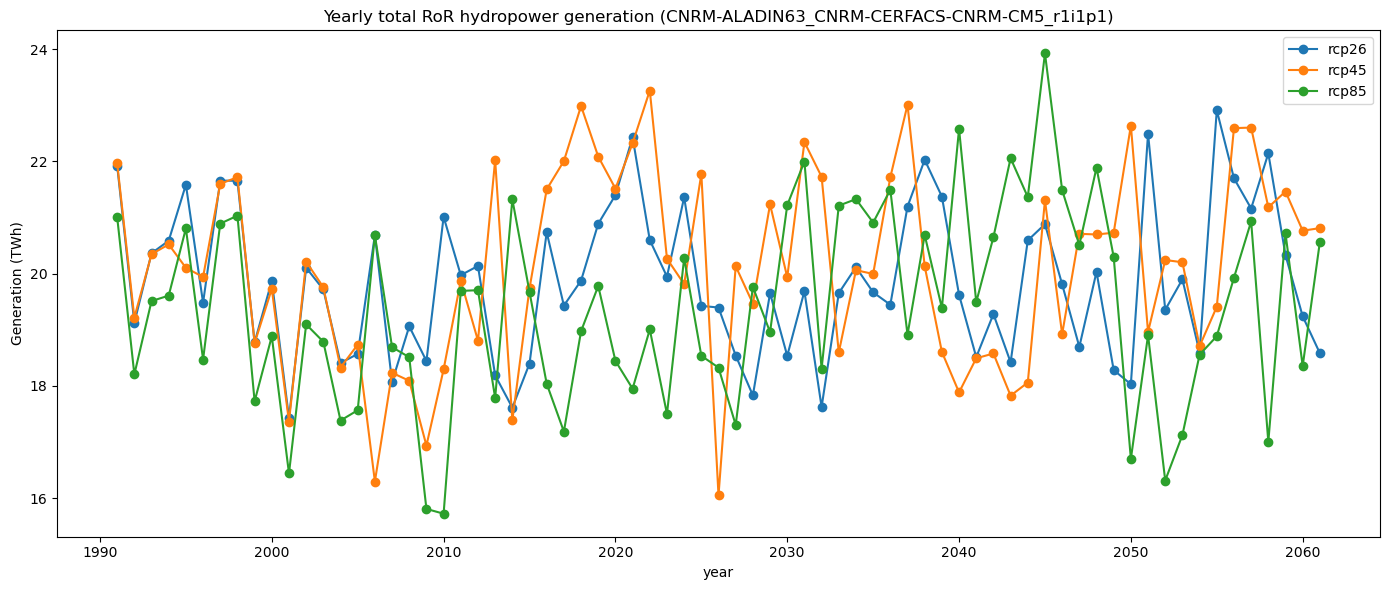

In [16]:
# plot both series
ax = df_combined.set_index("year").plot(
    figsize=(14, 6), marker="o", linestyle="-"
)
ax.set_title(f"Yearly total RoR hydropower generation ({climate_model_chain})")
ax.set_ylabel("Generation (TWh)")
ax.legend(["rcp26", "rcp45","rcp85"])
plt.tight_layout()

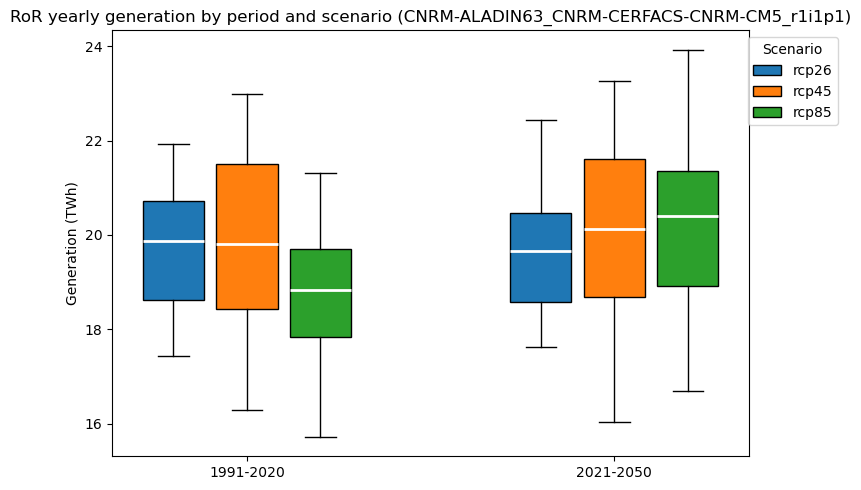

In [17]:
from matplotlib.patches import Patch
import numpy as np

# prepare data per period and scenario
scenario_order = ["rcp26", "rcp45", "rcp85"]
scenario_to_df = {"rcp26": df26, "rcp45": df45, "rcp85": df85}
scenario_colors = {"rcp26": "C0", "rcp45": "C1", "rcp85": "C2"}

group_bases = np.array([0.0, 3.0])  # center positions for the two periods
offsets = np.array([-0.6, 0.0, 0.6])  # offsets for the three scenarios within a group
positions = []
data_list = []
period_labels = []

for i, (pname, (y0, y1)) in enumerate(periods.items()):
    base = group_bases[i]
    for off, scen in zip(offsets, scenario_order):
        pos = base + off
        positions.append(pos)
        df = scenario_to_df[scen]
        vals = df[(df.year >= y0) & (df.year <= y1)]["gen_yearly"].to_numpy()
        data_list.append(vals)
    period_labels.append(pname)

# plotting
fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(data_list, positions=positions, widths=0.5, patch_artist=True, showfliers=False)

# color boxes by scenario
for i, patch in enumerate(box["boxes"]):
    scen = scenario_order[i % 3]
    color = scenario_colors[scen]
    patch.set_facecolor(color)
    patch.set_edgecolor("k")
    # whiskers/caps/medians
    box["whiskers"][2 * i].set_color("k")
    box["whiskers"][2 * i + 1].set_color("k")
    box["caps"][2 * i].set_color("k")
    box["caps"][2 * i + 1].set_color("k")
    box["medians"][i].set_color("white")
    box["medians"][i].set_linewidth(2)

# xticks centered per group
group_centers = [np.mean(positions[i * 3 : i * 3 + 3]) for i in range(len(group_bases))]
ax.set_xticks(group_centers)
ax.set_xticklabels(period_labels)
ax.set_ylabel("Generation (TWh)")
ax.set_title(f"RoR yearly generation by period and scenario ({climate_model_chain})")

# legend
legend_handles = [Patch(facecolor=scenario_colors[s], edgecolor="k", label=s) for s in scenario_order]
ax.legend(handles=legend_handles, title="Scenario", loc="upper right", bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

In [18]:
ds_trends_rcp26 = compute_theilsen_trends(df_combined, "gen_yearly_rcp26")
ds_trends_rcp45 = compute_theilsen_trends(df_combined, "gen_yearly_rcp45")
ds_trends_rcp85 = compute_theilsen_trends(df_combined, "gen_yearly_rcp85")

# keep per-scenario results and a combined lookup
ds_trends = pd.concat(
    [
        ds_trends_rcp26.assign(scenario="rcp26"),
        ds_trends_rcp45.assign(scenario="rcp45"),
        ds_trends_rcp85.assign(scenario="rcp85"),
    ]
).reset_index().set_index(["scenario", "period"])

display(ds_trends)

n_years  slope_TWh_per_year  slope_TWh_per_decade  \
scenario period                                                         
rcp26    1991-2020       30           -0.031323             -0.313226   
         2021-2050       30           -0.029396             -0.293960   
rcp45    1991-2020       30            0.003441              0.034408   
         2021-2050       30           -0.043696             -0.436961   
rcp85    1991-2020       30           -0.040766             -0.407657   
         2021-2050       30            0.101430              1.014301   

                    slope_CI_lower  slope_CI_upper   mean_TWh  \
scenario period                                                 
rcp26    1991-2020       -0.088276        0.038398  19.772241   
         2021-2050       -0.085737        0.020723  19.688822   
rcp45    1991-2020       -0.087131        0.102809  19.802602   
         2021-2050       -0.120550        0.042277  20.209797   
rcp85    1991-2020       -0.096916        0.027323  18.847630   
         2021-2050        0.031271        0.160778  20.134164   

                    rel_change_pct_per_decade                      method  
scenario period                                                            
rcp26    1991-2020                  -1.584171  scipy.theilslopes (95% CI)  
         2021-2050                  -1.493029  scipy.theilslopes (95% CI)  
rcp45    1991-2020                   0.173757  scipy.theilslopes (95% CI)  
         2021-2050                  -2.162125  scipy.theilslopes (95% CI)  
rcp85    1991-2020                  -2.162910  scipy.theilslopes (95% CI)  
         2021-2050                   5.037711  scipy.theilslopes (95% CI)

## Comparison to observation

In [19]:
df_reported_generation = pd.read_csv(
    processing.path_data_ror
    / "energy"
    / "ogd35_schweizerische_elektrizitaetsbilanz_monatswerte.csv"
)
df_reported_generation_ror = df_reported_generation[df_reported_generation.Jahr < 2023][
    ["Jahr", "Monat", "Erzeugung_laufwerk_GWh"]
].rename({"Erzeugung_laufwerk_GWh": "Reported Generation"}, axis=1)
df_reported_generation_ror["Reported Generation"] *= 1e-3  # to TWh

In [20]:
# compute using the dataset for the currently selected climate_scenario
for scenario in climate_scenarios:
    print(f"Processing scenario: {scenario}")
    ds_hydropower_generation_per_month = compute_monthly_generation_from_ds(
        ds_gen_dict[scenario], processing.gdf_hydropower_locations, start_year=2000
    )

    df_reported_generation_ror[f"Estimated Generation_{scenario}"] = (
        ds_hydropower_generation_per_month.sel(time=slice("2000", str(df_reported_generation_ror["Jahr"].max()))).gen.to_numpy()
    )

Processing scenario: rcp26
Processing scenario: rcp45
Processing scenario: rcp85


In [21]:
df_monthly_means = df_reported_generation_ror.groupby(df_reported_generation_ror["Monat"]).mean()
for scenario in climate_scenarios:
    df_monthly_means[f"Relative Bias_{scenario}"] = df_monthly_means[f"Estimated Generation_{scenario}"] / df_monthly_means["Reported Generation"]
df_monthly_means

,Jahr,Reported Generation,Estimated Generation_rcp26,Estimated Generation_rcp45,Estimated Generation_rcp85,Relative Bias_rcp26,Relative Bias_rcp45,Relative Bias_rcp85
Monat,,,,,,,,
1,2011.0,0.901043,0.863660,0.889548,0.810104,0.958511,0.987242,0.899073
2,2011.0,0.799000,0.793080,0.810691,0.726019,0.992591,1.014633,0.908660
3,2011.0,0.977826,1.053026,1.054297,0.933779,1.076905,1.078205,0.954954
4,2011.0,1.246826,1.491810,1.500013,1.333192,1.196486,1.203065,1.069268
5,2011.0,1.871870,2.079310,2.070373,2.025756,1.110820,1.106046,1.082210
6,2011.0,2.143652,2.304693,2.343769,2.207330,1.075125,1.093353,1.029706
7,2011.0,2.150348,2.249128,2.244795,2.131842,1.045937,1.043922,0.991394
8,2011.0,1.943522,1.955482,1.992646,1.910107,1.006154,1.025276,0.982807
9,2011.0,1.458000,1.726471,1.763771,1.602548,1.184137,1.209720,1.099141


In [22]:
bias_correction_factors = {}
for scenario in climate_scenarios:
    monthly_values = (
        1 / df_monthly_means[f"Relative Bias_{scenario}"]
    ).to_numpy()
    indices_months = ds_gen_dict[scenario].groupby("time.month").groups
    monthly_bias_correction_factors = np.empty(len(ds_gen_dict[scenario].time))
    for i, month in enumerate(indices_months):
        monthly_bias_correction_factors[indices_months[month]] = monthly_values[i]

    bias_correction_factors[scenario] = xr.DataArray(
        monthly_bias_correction_factors,
        dims=["time"],
        coords={"time": (["time"], ds_gen_dict[scenario].time.values)},
        name="bias_correction_factor",
    )

In [23]:
df_reported_generation_ror_corrected = df_reported_generation_ror.copy()
for scenario in climate_scenarios:
    df_reported_generation_ror_corrected[f"Estimated Generation_{scenario}"] = df_reported_generation_ror_corrected.apply(lambda r: r[f"Estimated Generation_{scenario}"] * (1 / df_monthly_means[f"Relative Bias_{scenario}"]).loc[r["Monat"]].item(), axis=1)

<Axes: title={'center': 'Corrected RoR generation'}>

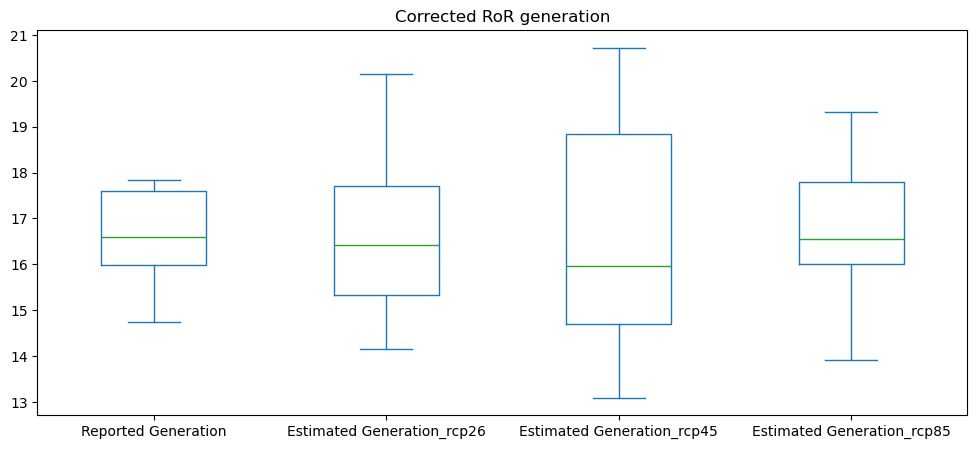

In [24]:
df_reported_generation_ror_corrected.groupby("Jahr").sum()[["Reported Generation", "Estimated Generation_rcp26", "Estimated Generation_rcp45", "Estimated Generation_rcp85"]].plot(kind="box", title="Corrected RoR generation", figsize=(12,5))

In [25]:
yearly_da_rcp26_corrected, df26_corrected, series26_corrected, yearly_values_rcp26_corrected = compute_yearly_sum_from_dataset(ds_gen_rcp26 * bias_correction_factors["rcp26"], "gen_yearly")
yearly_da_rcp45_corrected, df45_corrected, series45_corrected, yearly_values_rcp45_corrected = compute_yearly_sum_from_dataset(ds_gen_rcp45 * bias_correction_factors["rcp45"], "gen_yearly")
yearly_da_rcp85_corrected, df85_corrected, series85_corrected, yearly_values_rcp85_corrected = compute_yearly_sum_from_dataset(ds_gen_rcp85 * bias_correction_factors["rcp85"], "gen_yearly")

# combine into one dataframe (aligned by year)
df_combined = pd.merge(
    df26_corrected[["year", "gen_yearly"]],
    df45_corrected[["year", "gen_yearly"]],
    on="year",
    suffixes=("_rcp26", "_rcp45"),
)
df_combined_corrected = pd.merge(
    df_combined,
    df85_corrected[["year", "gen_yearly"]].rename({"gen_yearly": "gen_yearly_rcp85"}, axis=1),
    on="year",
)

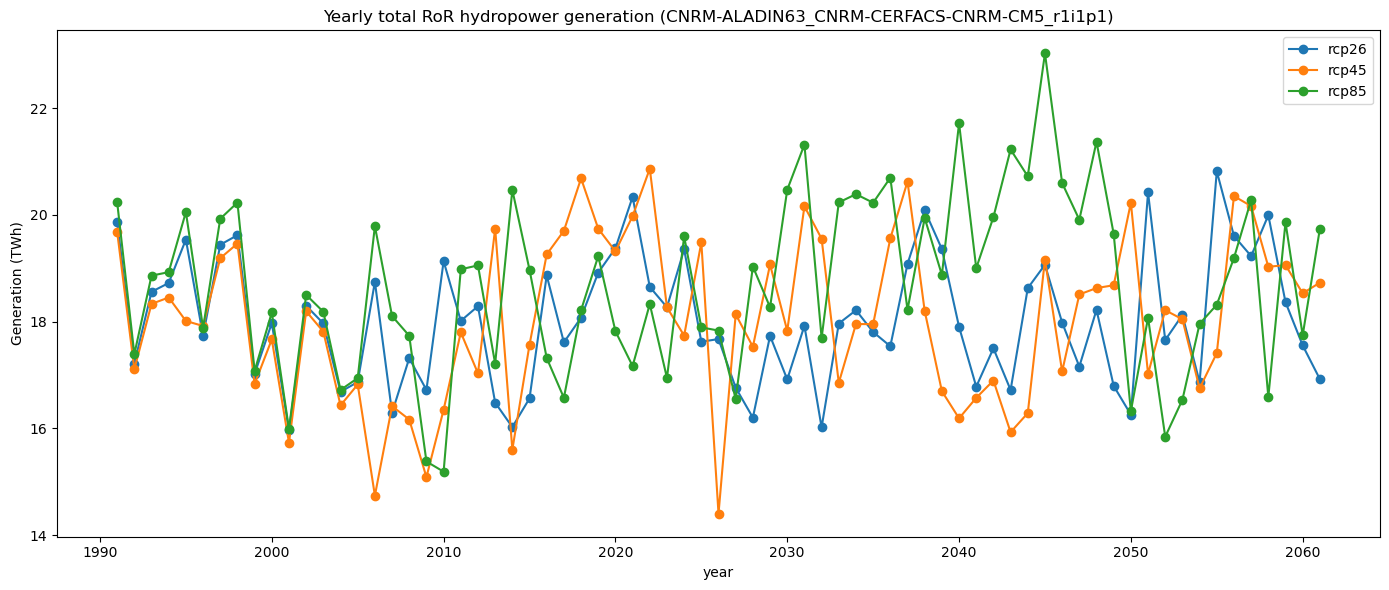

In [26]:
# plot both series
ax = df_combined_corrected.set_index("year").plot(
    figsize=(14, 6), marker="o", linestyle="-"
)
ax.set_title(f"Yearly total RoR hydropower generation ({climate_model_chain})")
ax.set_ylabel("Generation (TWh)")
ax.legend(["rcp26", "rcp45","rcp85"])
plt.tight_layout()

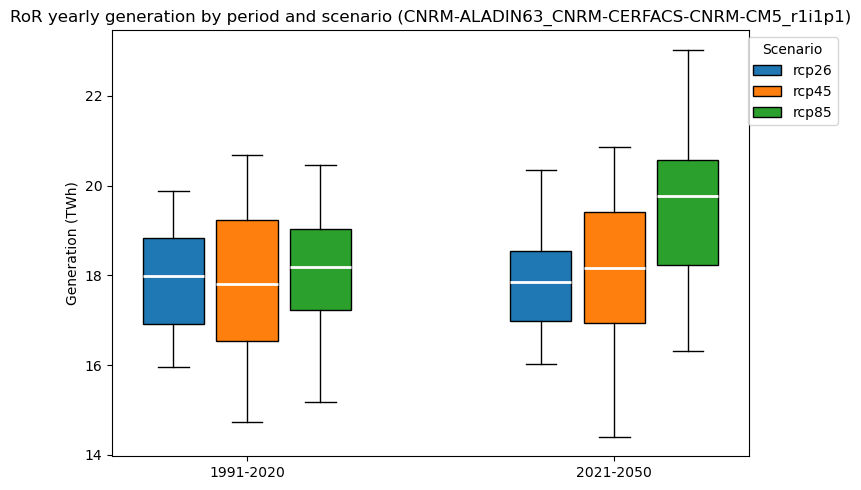

In [27]:
from matplotlib.patches import Patch
import numpy as np

# prepare data per period and scenario
scenario_order = ["rcp26", "rcp45", "rcp85"]
scenario_to_df = {"rcp26": df26_corrected, "rcp45": df45_corrected, "rcp85": df85_corrected}
scenario_colors = {"rcp26": "C0", "rcp45": "C1", "rcp85": "C2"}

group_bases = np.array([0.0, 3.0])  # center positions for the two periods
offsets = np.array([-0.6, 0.0, 0.6])  # offsets for the three scenarios within a group
positions = []
data_list = []
period_labels = []

for i, (pname, (y0, y1)) in enumerate(periods.items()):
    base = group_bases[i]
    for off, scen in zip(offsets, scenario_order):
        pos = base + off
        positions.append(pos)
        df = scenario_to_df[scen]
        vals = df[(df.year >= y0) & (df.year <= y1)]["gen_yearly"].to_numpy()
        data_list.append(vals)
    period_labels.append(pname)

# plotting
fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(data_list, positions=positions, widths=0.5, patch_artist=True, showfliers=False)

# color boxes by scenario
for i, patch in enumerate(box["boxes"]):
    scen = scenario_order[i % 3]
    color = scenario_colors[scen]
    patch.set_facecolor(color)
    patch.set_edgecolor("k")
    # whiskers/caps/medians
    box["whiskers"][2 * i].set_color("k")
    box["whiskers"][2 * i + 1].set_color("k")
    box["caps"][2 * i].set_color("k")
    box["caps"][2 * i + 1].set_color("k")
    box["medians"][i].set_color("white")
    box["medians"][i].set_linewidth(2)

# xticks centered per group
group_centers = [np.mean(positions[i * 3 : i * 3 + 3]) for i in range(len(group_bases))]
ax.set_xticks(group_centers)
ax.set_xticklabels(period_labels)
ax.set_ylabel("Generation (TWh)")
ax.set_title(f"RoR yearly generation by period and scenario ({climate_model_chain})")

# legend
legend_handles = [Patch(facecolor=scenario_colors[s], edgecolor="k", label=s) for s in scenario_order]
ax.legend(handles=legend_handles, title="Scenario", loc="upper right", bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

In [30]:
output_dir = Path("/net/exo/landclim_nobackup/FTP/yhaddad/")
for scen in ds_gen_dict.keys():
    print(f"Saving corrected dataset for scenario: {scen}")
    output_path = output_dir / "hydropower_ch" / f"ds_hydropower_ror_{processing.climate_model_chain}_{scen}.nc"
    if not output_path.exists():
        with ProgressBar(dt=1):
            (ds_gen_dict[scen] * bias_correction_factors[scen]).sel(time=slice("2018", "2052")).to_netcdf(output_path, mode="w")

[########################################] | 100% Completed | 290.50 s
[########################################] | 100% Completed | 283.45 s
[########################################] | 100% Completed | 187.73 s
